# Program Seleksi Fitur: Pearson Correlation & Information Gain

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

## Pra-pemrosesan sederhana

In [2]:
# Ganti path sesuai lokasi file kamu
df = pd.read_csv("heart.csv")

# Ambil 5 fitur + 1 target
df = df[['age', 'cp', 'thalach', 'oldpeak', 'ca', 'target']]

In [3]:
# Cek missing value
print("Jumlah nilai null per kolom:")
print(df.isnull().sum())

Jumlah nilai null per kolom:
age        0
cp         0
thalach    0
oldpeak    0
ca         0
target     0
dtype: int64


## Menghitung Pearson Correlation antara setiap fitur numerik dan target

=== Pearson Correlation Coefficient terhadap target ===
age       -0.225439
cp         0.433798
thalach    0.421741
oldpeak   -0.430696
ca        -0.391724
Name: target, dtype: float64


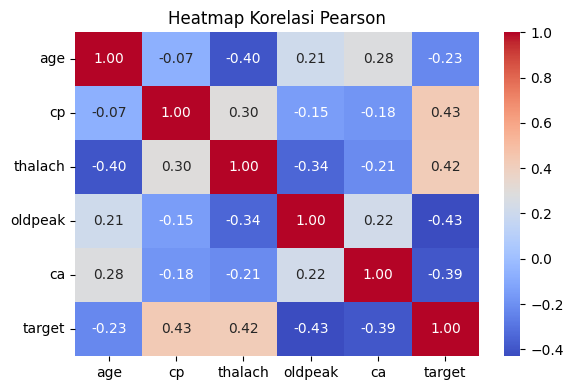

In [10]:
# Korelasi antar semua kolom (termasuk target)
correlation_matrix = df.corr()

# Ambil korelasi antara fitur dan target saja (drop target-target = 1.0)
pearson_corr = correlation_matrix["target"].drop("target")

# Tampilkan hasil korelasi
print("=== Pearson Correlation Coefficient terhadap target ===")
print(pearson_corr)

# Heatmap untuk semua kolom (bisa lihat hubungan antar fitur juga)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Pearson")
plt.tight_layout()
plt.show()


## Menghitung Information Gain untuk setiap fitur terhadap target

In [8]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns='target')
y = df['target']

# Hitung Information Gain untuk setiap fitur terhadap target
info_gain = mutual_info_classif(X, y, discrete_features='auto', random_state=42)

# Buat tabel hasil
info_gain_df = pd.DataFrame({
    'Feature': X.columns,
    'Information Gain': info_gain
}).sort_values(by='Information Gain', ascending=False)

# Tampilkan hasil
print("=== Information Gain untuk setiap fitur terhadap target ===")
print(info_gain_df)

=== Information Gain untuk setiap fitur terhadap target ===
   Feature  Information Gain
1       cp          0.157258
4       ca          0.129381
2  thalach          0.083959
3  oldpeak          0.081790
0      age          0.003101


## Visualisasi perbandingan Pearson Correlation dengan Information Gain

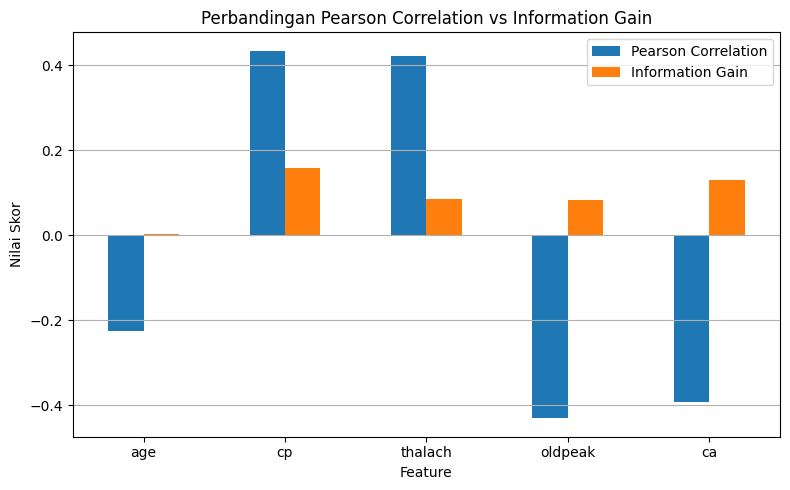

In [11]:
# Gabungkan ke DataFrame
comparison_df = pd.DataFrame({
    'Feature': X.columns,
    'Pearson Correlation': pearson_corr.values,
    'Information Gain': info_gain
})

# Plot bar chart perbandingan
comparison_df.set_index('Feature').plot(kind='bar', figsize=(8, 5))
plt.title('Perbandingan Pearson Correlation vs Information Gain')
plt.ylabel('Nilai Skor')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()